**EventTech 2026:: Validation, EDA, Cross-tabs, ROI & Gap Analysis**

This notebook is designed for the raw EventTech2026.xlsx survey export.
It covers:
- data-quality / response-base checks;
- validation of the current PowerPoint headline metrics;
- correct handling of multi-select questions;
- NPS validation;
- cross-tabs with statistical tests and effect sizes;
- organisation-size / industry significance checks;
- Spearman correlation matrix centred on ROI;
- ROI maturity deep dives;
- AI adoption vs data-readiness gaps;
- perceived integration vs actual system/data flow;
- open-text exploration;

In [5]:
# Import simple libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Load the survey dataset

file_path = "EventTech2026.xlsx"

df = pd.read_excel(file_path)

print("Number of responses:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of responses: 172
Number of columns: 40


In [8]:
# Preview the dataset

display(df.head(10))

,Unnamed: 0,Response status,Which best describes your job title? Please select one.,Which of the following best describes your role within your organisation? Please select one.,Which region is your organisation headquartered in?,Approximately how many employees does your organisation have?,Which best describes your organisation's primary industry?,What formats do the events you run take? Select all that apply.,Roughly how many branded/owned events does your organisation run per year?,How has the number of events your organisation runs changed in the past 12 months?,"“Event technology should now be considered part of our martech ecosystem, not a standalone category.” How much do you agree on a scale of 1-5, where 1 is Strongly disagree and 5 is Strongly agree?",Which of the following event technology tools does your organisation currently use? Select all that apply.,"Is your Event Tech strategy focused on an all-in-one platform, or a best-of-breed approach using specialist tools for each component?",Which single platform is most critical to how you run events?,"How likely are you to recommend your most critical event technology platform to a peer? Please use a scale of 0-10, where 0 is not at all likely, and 10 is extremely likely.",What's the main reason for that score?,Approximately what share of your total marketing/martech budget is allocated specifically to event technology?,"How would you describe the relationship between your events, marketing and sales teams and systems today?","How much of your event technology data (registration, attendance, engagement, lead capture) flows automatically into your core marketing automation platform, with no manual export/import?","How much of your event technology data flows automatically into your CRM (sales) system specifically, with no manual export/import?",Which best describes how your event technology connects to your core marketing/sales stack? Please select one.,"To what extent is event engagement data (e.g. session attendance, booth/stand visits, content engagement) captured in a structured and consistent way across your programme? Please use a scale of 1-5, where 1 is not at all structured and consistent, and 5 is extremely structured and consistent.","To what extent does event engagement data (e.g. session attendance, booth/stand visits, content engagement) influence how your sales team prioritises follow-up? Please use a scale of 1-5, where 1 is not at all and 5 is fully drives prioritisation.",Which event data types are hardest to get into your core marketing/sales stack? Please select up to three.,What's the biggest barrier to integrating event technology with your core martech stack? Please select one.,Which best describes your post-event follow-up process? Please select one.,"On average, how long after an event does first personalised follow-up reach an attendee or lead?",To what extent does your organisation have a single source of truth for event performance data?,Which AI-enabled event capabilities are you using or piloting? Select all that apply.,"“Our event data is ready to support AI-driven personalisation and recommendations.” How much do you agree? Please use a scale of 1-5, where 1 is strongly disagree and 5 is strongly agree",What's the single biggest barrier to AI adoption in your event technology? Please select one.,Who owns event technology strategy and vendor selection in your organisation?,"How confident are you that your team has the skills to get full value from your event technology? Please use a scale of 1-5, where 1 is not at all confident, and 5 is extremely confident",How is event technology training provided to your team?,Can you measure the pipeline or revenue contribution of your events in any form?,At what level is event ROI typically measured?,"How well aligned are your sales and events teams on lead follow-up and attribution? Please use a scale of 1-5, where 1 is not at all aligned, and 5 is extremely aligned.",How do you expect your event te

In [11]:
# Build robust short aliases for long survey-question headers
def find_col(fragment, case=False):
    fragment_cmp = fragment if case else fragment.lower()
    matches = []
    for c in df.columns:
        c_cmp = str(c) if case else str(c).lower()
        if fragment_cmp in c_cmp:
            matches.append(c)
    if len(matches) != 1:
        raise ValueError(f"Expected exactly 1 column matching {fragment!r}; found {len(matches)}: {matches}")
    return matches[0]

C = {
    "id": df.columns[0],
    "status": find_col("Response status"),
    "job": find_col("best describes your job title"),
    "role": find_col("role within your organisation"),
    "region": find_col("region is your organisation headquartered"),
    "size": find_col("how many employees"),
    "industry": find_col("primary industry"),
    "formats": find_col("formats do the events you run take"),
    "events_per_year": find_col("branded/owned events does your organisation run per year"),
    "event_change": find_col("number of events your organisation runs changed"),
    "eventtech_martech": find_col("considered part of our martech ecosystem"),
    "tools": find_col("event technology tools does your organisation currently use"),
    "stack_strategy": find_col("all-in-one platform, or a best-of-breed"),
    "critical_platform": find_col("single platform is most critical"),
    "nps": find_col("likely are you to recommend your most critical"),
    "nps_reason": find_col("main reason for that score"),
    "budget_share": find_col("share of your total marketing/martech budget"),
    "team_system_relation": find_col("relationship between your events, marketing and sales"),
    "map_flow": find_col("flows automatically into your core marketing automation"),
    "crm_flow": find_col("flows automatically into your CRM"),
    "integration_type": find_col("connects to your core marketing/sales stack"),
    "structured_data": find_col("captured in a structured and consistent way"),
    "data_followup": find_col("influence how your sales team prioritises follow-up"),
    "hard_data": find_col("data types are hardest to get into"),
    "integration_barrier": find_col("biggest barrier to integrating event technology"),
    "followup_process": find_col("best describes your post-event follow-up process"),
    "followup_time": find_col("how long after an event does first personalised follow-up"),
    "ssot": find_col("single source of truth for event performance"),
    "ai_caps": find_col("AI-enabled event capabilities"),
    "ai_ready": find_col("ready to support AI-driven personalisation"),
    "ai_barrier": find_col("biggest barrier to AI adoption"),
    "ownership": find_col("owns event technology strategy"),
    "skills": find_col("skills to get full value"),
    "training": find_col("training provided to your team"),
    "roi_measure": find_col("measure the pipeline or revenue contribution"),
    "roi_level": find_col("level is event ROI typically measured"),
    "sales_alignment": find_col("aligned are your sales and events teams"),
    "budget_change": find_col("event technology budget to change"),
    "budget_driver": find_col("primary driver of that change"),
    "unlock": find_col("single improvement would unlock"),
}

pd.DataFrame({"alias": C.keys(), "column": C.values()})


,alias,column
0,id,Unnamed: 0
1,status,Response status
2,job,Which best describes your job title? Please se...
3,role,Which of the following best describes your rol...
4,region,Which region is your organisation headquartere...
5,size,Approximately how many employees does your org...
6,industry,Which best describes your organisation's prima...
7,formats,What formats do the events you run take? Selec...
8,events_per_year,Roughly how many branded/owned events does you...
9,event_change,How has the number of events your organisation...


In [12]:
print("Total rows:", len(df))
display(df[C["status"]].value_counts(dropna=False).to_frame("count"))

base = pd.DataFrame({
    "alias": list(C.keys()),
    "question": [C[k] for k in C],
    "non_missing_n": [df[C[k]].notna().sum() for k in C],
})
base["missing_n"] = len(df) - base["non_missing_n"]
base["response_rate_%"] = 100 * base["non_missing_n"] / len(df)

display(base.sort_values("non_missing_n"))

# Expectation from the current deck:
# 172 total; 149 completed; 23 partial.


Total rows: 172


,count
Response status,
COMPLETED,149
PARTIAL,23


,alias,question,non_missing_n,missing_n,response_rate_%
39,unlock,"Finally, what single improvement would unlock ...",149,23,86.627907
38,budget_driver,What's the primary driver of that change? Plea...,149,23,86.627907
37,budget_change,How do you expect your event technology budget...,149,23,86.627907
36,sales_alignment,How well aligned are your sales and events tea...,150,22,87.209302
35,roi_level,At what level is event ROI typically measured?,150,22,87.209302
34,roi_measure,Can you measure the pipeline or revenue contri...,150,22,87.209302
24,integration_barrier,What's the biggest barrier to integrating even...,151,21,87.790698
25,followup_process,Which best describes your post-event follow-up...,151,21,87.790698
26,followup_time,"On average, how long after an event does first...",151,21,87.790698
27,ssot,To what extent does your organisation have a s...,151,21,87.790698


In [14]:
def pct(n, d, digits=1):
    if d == 0:
        return np.nan
    return round(100 * n / d, digits)


def value_table(col):
    s = df[col].dropna()
    out = s.value_counts().rename("n").to_frame()
    out["%"] = (100 * out["n"] / len(s)).round(1)
    return out


def parse_nps(series):
    # Works for values such as "9 (Promoter)" or just 9
    return pd.to_numeric(
        series.astype(str).str.extract(r"^(\d+)")[0],
        errors="coerce"
    )


def nps_summary(series):
    x = parse_nps(series).dropna()

    promoters = (x >= 9).sum()
    passives = ((x >= 7) & (x <= 8)).sum()
    detractors = (x <= 6).sum()

    n = len(x)

    return pd.Series({
        "n": n,
        "promoters_n": promoters,
        "passives_n": passives,
        "detractors_n": detractors,
        "promoters_%": round(100 * promoters / n, 1),
        "passives_%": round(100 * passives / n, 1),
        "detractors_%": round(100 * detractors / n, 1),
        "NPS": round(100 * (promoters - detractors) / n, 1)
    })

In [15]:
FORMAT_OPTIONS = {
    "hosted": "Hosted events (e.g. Conferences, Networking dinners)",
    "attend": "Attend events (e.g. Sponsorship activations and Trade shows)",
    "virtual": "Webinars/ Virtual events",
}

TOOL_OPTIONS = {
    "registration": "Registration / ticketing platform",
    "dedicated_platform": "Dedicated event management platform (e.g. Cvent, Bizzabo, Splash)",
    "virtual_platform": "Virtual / hybrid event platform",
    "mobile_app": "Mobile event app",
    "badge_rfid": "Badge scanning / RFID / location tracking",
    "lead_capture": "Lead retrieval / capture tools",
    "engagement_analytics": "Session or content engagement analytics",
    "ai_matchmaking": "AI matchmaking or networking tools",
    "sponsor_tech": "Sponsor / exhibitor activation technology",
}

AI_OPTIONS = {
    "ai_matchmaking": "AI matchmaking / networking recommendations",
    "ai_content_recs": "AI session or content recommendations for attendees",
    "ai_lead_scoring": "AI lead scoring",
    "ai_chatbots": "AI chatbots / attendee support",
    "ai_generated_content": "AI-generated event content or summaries",
}


def add_flags(source_col, options, prefix):
    text = df[source_col].fillna("").astype(str)

    for short_name, answer_text in options.items():
        df[f"{prefix}_{short_name}"] = text.str.contains(
            answer_text,
            regex=False
        )


add_flags(C["formats"], FORMAT_OPTIONS, "fmt")
add_flags(C["tools"], TOOL_OPTIONS, "tool")
add_flags(C["ai_caps"], AI_OPTIONS, "ai")

print("Multi-select flags created.")

Multi-select flags created.


In [16]:
def mean_score(alias):
    return pd.to_numeric(df[C[alias]], errors="coerce").mean()


# Response status
total_responses = len(df)
completed = (df[C["status"]] == "COMPLETED").sum()
partial = (df[C["status"]] == "PARTIAL").sum()


# Event growth
event_increased = df[C["event_change"]].isin([
    "Increased slightly",
    "Increased significantly (e.g. by a third or more)"
]).sum()


# Stack strategy
stack_base = df[C["stack_strategy"]].notna().sum()
best_of_breed = (
    df[C["stack_strategy"]] ==
    "We use specialist tools for each component"
).sum()


# Budget
budget_base = df[C["budget_share"]].notna().sum()
budget_10_19 = (df[C["budget_share"]] == "10–19%").sum()
budget_under_20 = df[C["budget_share"]].isin(
    ["Less than 10%", "10–19%"]
).sum()


# Follow-up
follow_base = df[C["followup_process"]].notna().sum()
fully_realtime = (
    df[C["followup_process"]] ==
    "Fully automated, real-time, and personalised at the individual level"
).sum()


# Single source of truth
ssot_base = df[C["ssot"]].notna().sum()
ssot_complete = (df[C["ssot"]] == "Completely").sum()


# AI adoption
ai_base = df[C["ai_caps"]].notna().sum()
ai_none = (
    df[C["ai_caps"]]
    .fillna("")
    .str.contains("None currently", regex=False)
    .sum()
)


# ROI
roi_base = df[C["roi_measure"]].notna().sum()
roi_any = df[C["roi_measure"]].isin(
    ["Yes, partially", "Yes, fully"]
).sum()
roi_full = (df[C["roi_measure"]] == "Yes, fully").sum()


roi_level_base = df[C["roi_level"]].notna().sum()
roi_business = (
    df[C["roi_level"]] ==
    "Tied to broader business/revenue outcomes"
).sum()
roi_programme = (
    df[C["roi_level"]] ==
    "Programme level (across a series of events)"
).sum()
roi_event = (
    df[C["roi_level"]] ==
    "Individual event level only"
).sum()


# NPS
overall_nps = nps_summary(df[C["nps"]])

cvent = (
    df[C["critical_platform"]]
    .fillna("")
    .str.strip()
    .str.lower()
    .eq("cvent")
)

cvent_nps = nps_summary(df.loc[cvent, C["nps"]])

platform_base = df[C["critical_platform"]].notna().sum()
cvent_share = 100 * cvent.sum() / platform_base


validation = pd.DataFrame({
    "Metric": [
        "Total responses",
        "Completed responses",
        "Partial responses",
        "Event Tech = MarTech mean",
        "Structured engagement data mean",
        "Data shapes follow-up mean",
        "AI-ready data mean",
        "Skills confidence mean",
        "Sales-events alignment mean",
        "Event volume increased",
        "Best-of-breed strategy",
        "Overall NPS",
        "Cvent share",
        "Cvent NPS",
        "Budget = 10–19%",
        "Budget under 20%",
        "Fully real-time personalised follow-up",
        "Complete single source of truth",
        "Using/piloting at least one AI capability",
        "Can measure some pipeline/revenue",
        "Can measure fully",
        "ROI tied to broader business/revenue",
        "ROI measured at programme level",
        "ROI measured at individual-event level",
    ],
    "Raw calculation": [
        total_responses,
        completed,
        partial,
        mean_score("eventtech_martech"),
        mean_score("structured_data"),
        mean_score("data_followup"),
        mean_score("ai_ready"),
        mean_score("skills"),
        mean_score("sales_alignment"),
        100 * event_increased / total_responses,
        100 * best_of_breed / stack_base,
        overall_nps["NPS"],
        cvent_share,
        cvent_nps["NPS"],
        100 * budget_10_19 / budget_base,
        100 * budget_under_20 / budget_base,
        100 * fully_realtime / follow_base,
        100 * ssot_complete / ssot_base,
        100 * (ai_base - ai_none) / ai_base,
        100 * roi_any / roi_base,
        100 * roi_full / roi_base,
        100 * roi_business / roi_level_base,
        100 * roi_programme / roi_level_base,
        100 * roi_event / roi_level_base,
    ],
    "PowerPoint value": [
        172, 149, 23,
        4.31, 3.89, 4.01, 3.93, 3.97, 4.01,
        74.5, 78.7, 48, 37, 55,
        48, 77, 2, 1, 97, 99, 10, 59, 33, 8
    ]
})

validation["Raw calculation"] = validation["Raw calculation"].round(2)
validation["Difference"] = (
    validation["Raw calculation"] -
    validation["PowerPoint value"]
).round(2)

display(validation)

,Metric,Raw calculation,PowerPoint value,Difference
0,Total responses,172.00,172.00,0.00
1,Completed responses,149.00,149.00,0.00
2,Partial responses,23.00,23.00,0.00
3,Event Tech = MarTech mean,4.31,4.31,0.00
4,Structured engagement data mean,3.89,3.89,0.00
5,Data shapes follow-up mean,4.01,4.01,0.00
6,AI-ready data mean,3.93,3.93,0.00
7,Skills confidence mean,3.97,3.97,0.00
8,Sales-events alignment mean,4.01,4.01,0.00
9,Event volume increased,74.42,74.50,-0.08


In [17]:
eventtech_scores = pd.to_numeric(
    df[C["eventtech_martech"]],
    errors="coerce"
).dropna()

display(
    eventtech_scores
    .value_counts()
    .sort_index()
    .rename("n")
    .to_frame()
)

positive = (eventtech_scores >= 4).sum()
neutral = (eventtech_scores == 3).sum()
negative = (eventtech_scores <= 2).sum()

print(
    "Agree / strongly agree:",
    positive,
    f"({pct(positive, len(eventtech_scores))}%)"
)

print(
    "Neutral:",
    neutral,
    f"({pct(neutral, len(eventtech_scores))}%)"
)

print(
    "Disagree / strongly disagree:",
    negative,
    f"({pct(negative, len(eventtech_scores))}%)"
)

,n
"“Event technology should now be considered part of our martech ecosystem, not a standalone category.” How much do you agree on a scale of 1-5, where 1 is Strongly disagree and 5 is Strongly agree?",
2.0,2
3.0,11
4.0,90
5.0,67


Agree / strongly agree: 157 (92.4%)
Neutral: 11 (6.5%)
Disagree / strongly disagree: 2 (1.2%)


In [18]:
# Organisation size vs attending external events

df["size_250_plus"] = np.where(
    df[C["size"]] == "Fewer than 250",
    "<250",
    "250+"
)

attend_table = pd.crosstab(
    df["size_250_plus"],
    df["fmt_attend"],
    normalize="index"
) * 100

display(attend_table.round(1))

fmt_attend,False,True
size_250_plus,,
250+,13.3,86.7
<250,35.1,64.9


In [19]:
# Virtual event use by industry

top_industries = [
    "Financial Services",
    "Software",
    "Travel, Tourism and Hospitality",
    "Business Services",
    "Technology",
]

virtual_by_industry = (
    df[df[C["industry"]].isin(top_industries)]
    .groupby(C["industry"])["fmt_virtual"]
    .agg(["mean", "count"])
)

virtual_by_industry["Virtual event use %"] = (
    100 * virtual_by_industry["mean"]
).round(1)

virtual_by_industry = virtual_by_industry[
    ["Virtual event use %", "count"]
].sort_values("Virtual event use %", ascending=False)

display(virtual_by_industry)

,Virtual event use %,count
Which best describes your organisation's primary industry?,,
Technology,94.1,17
Software,83.3,24
Business Services,72.2,18
Financial Services,67.9,28
"Travel, Tourism and Hospitality",33.3,21


In [20]:
# Event growth by organisation size

df["event_increased"] = df[C["event_change"]].isin([
    "Increased slightly",
    "Increased significantly (e.g. by a third or more)"
])

growth_by_size = (
    df.groupby(C["size"])["event_increased"]
    .agg(["mean", "count"])
)

growth_by_size["Increased %"] = (
    100 * growth_by_size["mean"]
).round(1)

display(
    growth_by_size[
        ["Increased %", "count"]
    ].sort_values("Increased %", ascending=False)
)

,Increased %,count
Approximately how many employees does your organisation have?,,
"2,500 - 10,000",89.8,49
"250 - 2,499",78.3,69
"More than 10,000",58.8,17
Fewer than 250,54.1,37


In [21]:
size_map = {
    "Fewer than 250": 1,
    "250 - 2,499": 2,
    "2,500 - 10,000": 3,
    "More than 10,000": 4
}

events_map = {
    "1-2": 1,
    "3-10": 2,
    "11-25": 3,
    "More than 25": 4
}

event_change_map = {
    "Decreased": 1,
    "Stayed about the same": 2,
    "Increased slightly": 3,
    "Increased significantly (e.g. by a third or more)": 4
}

budget_share_map = {
    "Less than 10%": 1,
    "10–19%": 2,
    "20–29%": 3,
    "30–39%": 4,
    "40–50%": 5,
    "More than 50%": 6
}

team_integration_map = {
    "Fully siloed — separate teams, separate systems, little coordination": 1,
    "Some collaboration, but still separate systems": 2,
    "Integrated processes, but separate teams": 3,
    "Fully integrated — shared team and/or shared systems": 4
}

data_flow_map = {
    "Very few or none": 1,
    "A small minority": 2,
    "About half": 3,
    "Most": 4,
    "Almost all": 5
}

followup_map = {
    "Manual / ad hoc — no consistent process": 1,
    "Some automation, but inconsistent across events": 2,
    "Mostly automated, and personalised by attendee segment": 3,
    "Fully automated, real-time, and personalised at the individual level": 4
}

followup_time_map = {
    "No consistent process": 1,
    "2+ weeks": 2,
    "Within a week": 3,
    "2–3 days": 4,
    "Same day": 5
}

ssot_map = {
    "Not at all": 1,
    "To a small extent/ we’re in the early stages": 2,
    "To a moderate extent/ partially": 3,
    "To a large extent": 4,
    "Completely": 5
}

training_map = {
    "No training provided": 1,
    "Ad hoc, in response to specific needs": 2,
    "Structured programme": 3,
    "Ongoing, continuous learning": 4
}

roi_measure_map = {
    "No": 0,
    "Yes, partially": 1,
    "Yes, fully": 2
}

roi_level_map = {
    "Not measured": 0,
    "Individual event level only": 1,
    "Programme level (across a series of events)": 2,
    "Tied to broader business/revenue outcomes": 3
}

budget_change_map = {
    "Significant decrease": 1,
    "Slight decrease": 2,
    "No change": 3,
    "Slight increase": 4,
    "Significant increase": 5
}


analysis = pd.DataFrame(index=df.index)

analysis["Organisation size"] = df[C["size"]].map(size_map)
analysis["Events per year"] = df[C["events_per_year"]].map(events_map)
analysis["Event volume change"] = df[C["event_change"]].map(event_change_map)

analysis["Event Tech = MarTech"] = pd.to_numeric(
    df[C["eventtech_martech"]],
    errors="coerce"
)

analysis["Event-tech budget share"] = df[C["budget_share"]].map(
    budget_share_map
)

analysis["Team/system integration"] = df[C["team_system_relation"]].map(
    team_integration_map
)

analysis["MAP auto-flow"] = df[C["map_flow"]].map(data_flow_map)
analysis["CRM auto-flow"] = df[C["crm_flow"]].map(data_flow_map)

analysis["Structured engagement data"] = pd.to_numeric(
    df[C["structured_data"]],
    errors="coerce"
)

analysis["Data shapes sales follow-up"] = pd.to_numeric(
    df[C["data_followup"]],
    errors="coerce"
)

analysis["Follow-up automation"] = df[C["followup_process"]].map(
    followup_map
)

analysis["Follow-up speed"] = df[C["followup_time"]].map(
    followup_time_map
)

analysis["Single source of truth"] = df[C["ssot"]].map(ssot_map)

analysis["AI-ready data"] = pd.to_numeric(
    df[C["ai_ready"]],
    errors="coerce"
)

analysis["Skills confidence"] = pd.to_numeric(
    df[C["skills"]],
    errors="coerce"
)

analysis["Training maturity"] = df[C["training"]].map(training_map)

analysis["Sales-events alignment"] = pd.to_numeric(
    df[C["sales_alignment"]],
    errors="coerce"
)

analysis["Budget outlook"] = df[C["budget_change"]].map(
    budget_change_map
)

analysis["ROI measurement ability"] = df[C["roi_measure"]].map(
    roi_measure_map
)

analysis["ROI measurement level"] = df[C["roi_level"]].map(
    roi_level_map
)

display(analysis.head())

,Organisation size,Events per year,Event volume change,Event Tech = MarTech,Event-tech budget share,Team/system integration,MAP auto-flow,CRM auto-flow,Structured engagement data,Data shapes sales follow-up,Follow-up automation,Follow-up speed,Single source of truth,AI-ready data,Skills confidence,Training maturity,Sales-events alignment,Budget outlook,ROI measurement ability,ROI measurement level
0,2,2,3,5.0,2.0,3.0,4.0,3.0,4.0,4.0,3.0,4.0,3.0,4.0,4.0,2.0,4.0,4.0,1.0,3.0
1,4,4,3,5.0,2.0,2.0,2.0,3.0,4.0,4.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,4.0,1.0,2.0
2,3,2,3,4.0,1.0,3.0,4.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,2,3,5.0,2.0,3.0,5.0,4.0,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,3,3,5.0,1.0,2.0,1.0,1.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
correlation_matrix = analysis.corr(method="spearman")

display(correlation_matrix.round(2))

,Organisation size,Events per year,Event volume change,Event Tech = MarTech,Event-tech budget share,Team/system integration,MAP auto-flow,CRM auto-flow,Structured engagement data,Data shapes sales follow-up,Follow-up automation,Follow-up speed,Single source of truth,AI-ready data,Skills confidence,Training maturity,Sales-events alignment,Budget outlook,ROI measurement ability,ROI measurement level
Organisation size,1.00,0.24,0.14,0.11,-0.18,0.06,-0.03,-0.01,0.02,0.08,0.02,-0.01,0.05,0.01,0.09,0.01,0.13,-0.06,-0.00,0.13
Events per year,0.24,1.00,0.15,0.11,0.09,0.16,0.06,0.11,0.10,0.05,0.10,-0.09,0.19,0.04,0.12,0.07,0.01,0.09,0.06,0.21
Event volume change,0.14,0.15,1.00,0.42,-0.00,0.31,0.12,0.15,0.22,0.09,0.09,0.18,0.09,0.21,0.14,0.01,0.19,-0.01,-0.02,-0.04
Event Tech = MarTech,0.11,0.11,0.42,1.00,-0.00,0.28,0.25,0.20,0.14,0.25,0.16,0.15,0.05,0.26,0.18,0.12,0.29,0.19,0.04,0.03
Event-tech budget share,-0.18,0.09,-0.00,-0.00,1.00,0.16,0.36,0.44,0.05,-0.05,0.42,0.04,0.40,0.08,0.09,0.28,0.03,0.19,0.43,-0.03
Team/system integration,0.06,0.16,0.31,0.28,0.16,1.00,0.38,0.33,0.34,0.28,0.41,0.23,0.36,0.32,0.43,0.32,0.50,0.42,0.13,0.30
MAP auto-flow,-0.03,0.06,0.12,0.25,0.36,0.38,1.00,0.85,0.12,0.17,0.72,0.23,0.70,0.14,0.29,0.36,0.14,0.23,0.17,0.15
CRM auto-flow,-0.01,0.11,0.15,0.20,0.44,0.33,0.85,1.00,0.23,0.17,0.72,0.35,0.75,0.12,0.36,0.40,0.21,0.20,0.26,0.13
Structured engagement data,0.02,0.10,0.22,0.14,0.05,0.34,0.12,0.23,1.00,0.33,0.15,0.33,0.11,0.31,0.41,0.11,0.54,0.45,0.02,0.16
Data shapes sales follow-up,0.08,0.05,0.09,0.25,-0.05,0.28,0.17,0.17,0.33,1.00,0.10,0.10,0.11,0.35,0.37,0.16,0.45,0.24,0.09,0.16


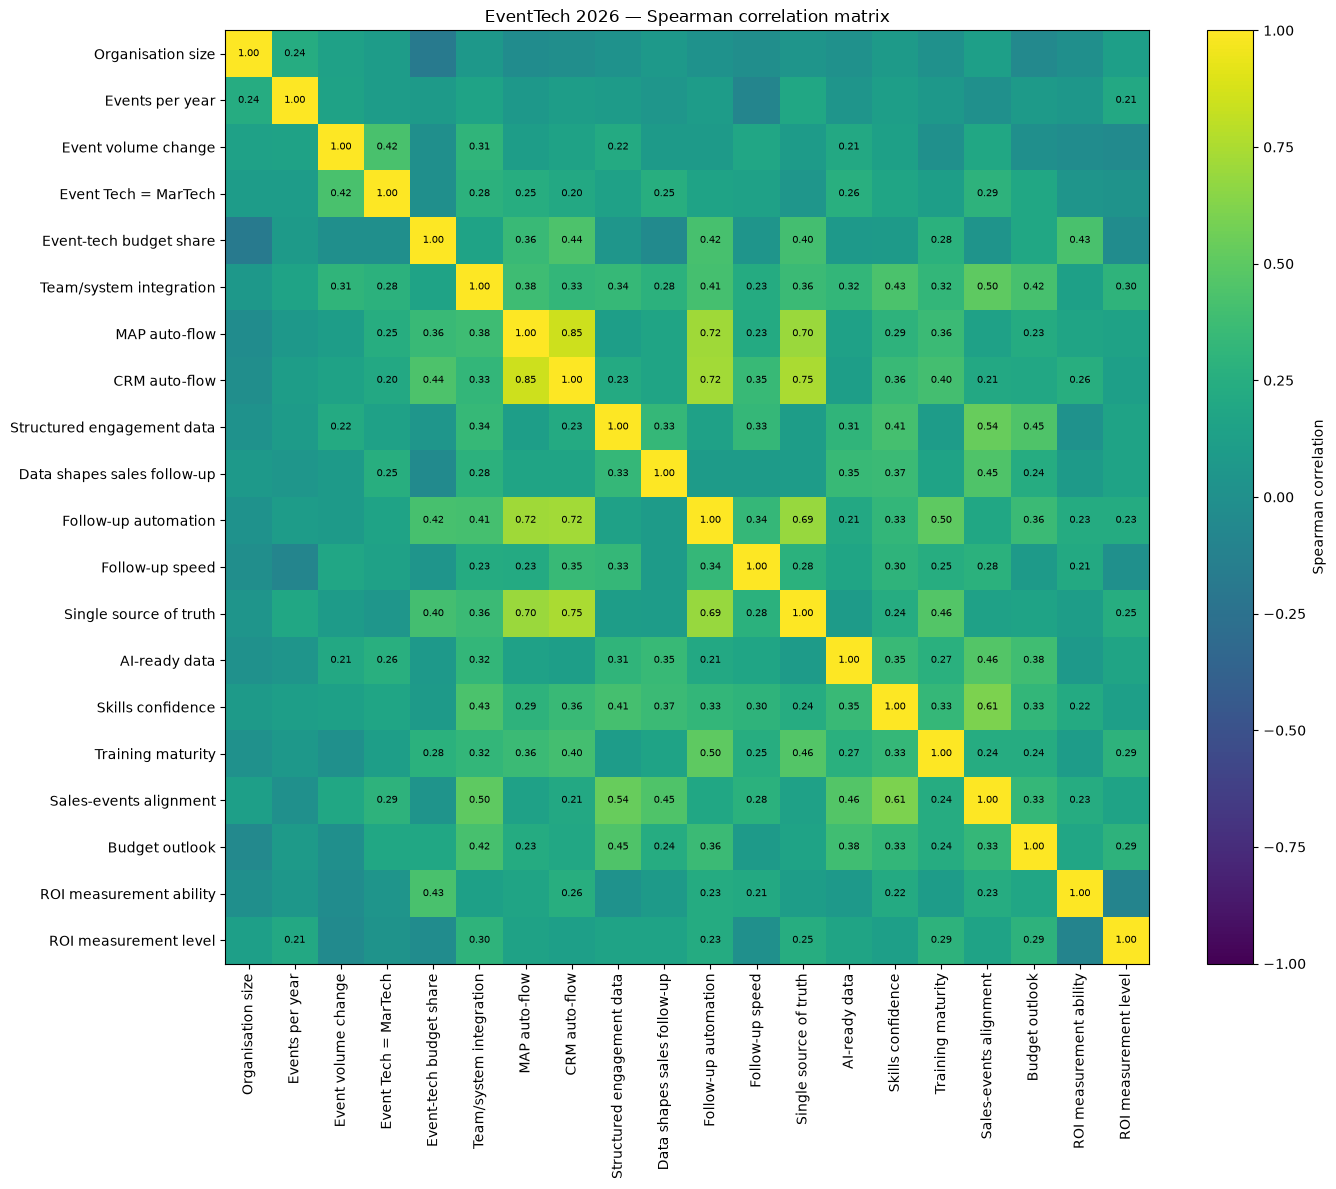

In [23]:
# Visual correlation matrix

fig, ax = plt.subplots(figsize=(14, 12))

image = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=90
)

ax.set_yticklabels(
    correlation_matrix.index
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[i, j]

        if abs(value) >= 0.20 or i == j:
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=7
            )

ax.set_title("EventTech 2026 — Spearman correlation matrix")

fig.colorbar(
    image,
    ax=ax,
    label="Spearman correlation"
)

plt.tight_layout()
plt.show()

In [24]:
roi_ability_correlations = (
    correlation_matrix["ROI measurement ability"]
    .drop("ROI measurement ability")
    .sort_values(key=abs, ascending=False)
    .to_frame("Correlation with ROI ability")
)

display(roi_ability_correlations.round(3))

,Correlation with ROI ability
Event-tech budget share,0.428
CRM auto-flow,0.255
Sales-events alignment,0.234
Follow-up automation,0.232
Skills confidence,0.219
Follow-up speed,0.213
Budget outlook,0.182
MAP auto-flow,0.169
Team/system integration,0.134
Single source of truth,0.117


In [25]:
roi_level_correlations = (
    correlation_matrix["ROI measurement level"]
    .drop("ROI measurement level")
    .sort_values(key=abs, ascending=False)
    .to_frame("Correlation with ROI level")
)

display(roi_level_correlations.round(3))

,Correlation with ROI level
Team/system integration,0.303
Budget outlook,0.293
Training maturity,0.289
Single source of truth,0.248
Follow-up automation,0.230
Events per year,0.211
AI-ready data,0.170
Structured engagement data,0.164
Sales-events alignment,0.160
Data shapes sales follow-up,0.158


In [26]:
df["roi_full"] = (
    df[C["roi_measure"]] ==
    "Yes, fully"
)

budget_order = [
    "Less than 10%",
    "10–19%",
    "20–29%",
    "30–39%",
    "40–50%",
    "More than 50%"
]

roi_by_budget = (
    df[
        df[C["budget_share"]].isin(budget_order) &
        df[C["roi_measure"]].notna()
    ]
    .groupby(C["budget_share"])["roi_full"]
    .agg(["mean", "count", "sum"])
    .reindex(budget_order)
)

roi_by_budget["Fully measurable ROI %"] = (
    100 * roi_by_budget["mean"]
).round(1)

display(
    roi_by_budget[
        ["Fully measurable ROI %", "sum", "count"]
    ]
)

,Fully measurable ROI %,sum,count
Approximately what share of your total marketing/martech budget is allocated specifically to event technology?,,,
Less than 10%,0.0,0,44
10–19%,2.8,2,71
20–29%,17.4,4,23
30–39%,100.0,4,4
40–50%,80.0,4,5
More than 50%,0.0,0,1


In [27]:
# Simpler comparison: under 20% vs 20%+

df["budget_20_plus"] = (
    df[C["budget_share"]]
    .map(budget_share_map)
    .ge(3)
)

simple_roi_budget = (
    df[
        df[C["roi_measure"]].notna() &
        df[C["budget_share"]].isin(budget_share_map)
    ]
    .groupby("budget_20_plus")["roi_full"]
    .agg(["mean", "sum", "count"])
)

simple_roi_budget["Fully measurable ROI %"] = (
    100 * simple_roi_budget["mean"]
).round(1)

simple_roi_budget.index = [
    "Under 20%",
    "20% or more"
]

display(
    simple_roi_budget[
        ["Fully measurable ROI %", "sum", "count"]
    ]
)

,Fully measurable ROI %,sum,count
Under 20%,1.7,2,115
20% or more,36.4,12,33


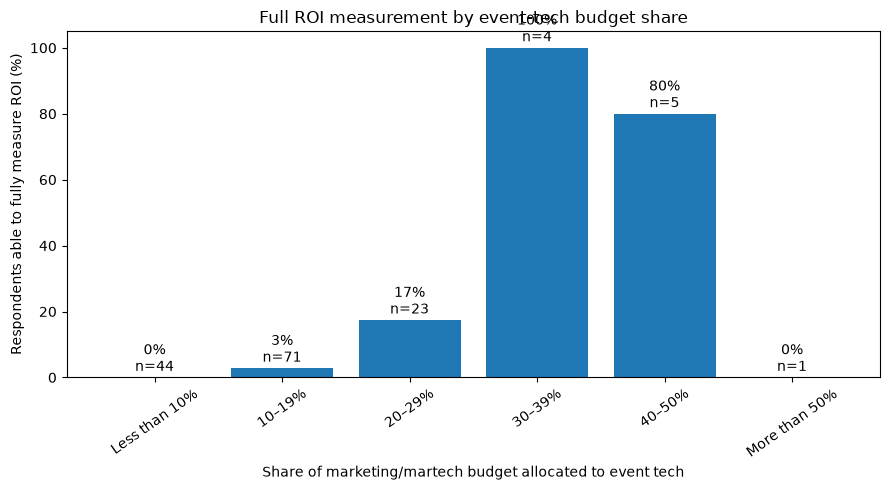

In [28]:
# Chart: ROI measurement by event-tech budget share

plot_data = roi_by_budget["Fully measurable ROI %"]

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    plot_data.index,
    plot_data.values
)

ax.set_title(
    "Full ROI measurement by event-tech budget share"
)

ax.set_ylabel(
    "Respondents able to fully measure ROI (%)"
)

ax.set_xlabel(
    "Share of marketing/martech budget allocated to event tech"
)

ax.tick_params(
    axis="x",
    rotation=35
)

for i, value in enumerate(plot_data.values):
    if pd.notna(value):
        n = roi_by_budget.iloc[i]["count"]

        ax.text(
            i,
            value + 2,
            f"{value:.0f}%\nn={int(n)}",
            ha="center"
        )

plt.tight_layout()
plt.show()

In [29]:
df["alignment_group"] = np.where(
    pd.to_numeric(
        df[C["sales_alignment"]],
        errors="coerce"
    ) == 5,
    "Alignment = 5",
    "Alignment below 5"
)

roi_by_alignment = (
    df[df[C["roi_measure"]].notna()]
    .groupby("alignment_group")["roi_full"]
    .agg(["mean", "sum", "count"])
)

roi_by_alignment["Fully measurable ROI %"] = (
    100 * roi_by_alignment["mean"]
).round(1)

display(
    roi_by_alignment[
        ["Fully measurable ROI %", "sum", "count"]
    ]
)

,Fully measurable ROI %,sum,count
alignment_group,,,
Alignment = 5,31.8,7,22
Alignment below 5,6.2,8,128


In [30]:
roi_cross = pd.crosstab(
    df[C["roi_measure"]],
    df[C["roi_level"]]
)

display(roi_cross)

roi_cross_pct = (
    pd.crosstab(
        df[C["roi_measure"]],
        df[C["roi_level"]],
        normalize="index"
    ) * 100
).round(1)

display(roi_cross_pct)

print(
    "Spearman correlation between the two ROI questions:",
    round(
        analysis[
            ["ROI measurement ability", "ROI measurement level"]
        ]
        .corr(method="spearman")
        .iloc[0, 1],
        3
    )
)

At what level is event ROI typically measured?,Individual event level only,Not measured,Programme level (across a series of events),Tied to broader business/revenue outcomes
Can you measure the pipeline or revenue contribution of your events in any form?,,,,
No,0,1,0,0
"Yes, fully",3,0,6,6
"Yes, partially",9,0,43,82


At what level is event ROI typically measured?,Individual event level only,Not measured,Programme level (across a series of events),Tied to broader business/revenue outcomes
Can you measure the pipeline or revenue contribution of your events in any form?,,,,
No,0.0,100.0,0.0,0.0
"Yes, fully",20.0,0.0,40.0,40.0
"Yes, partially",6.7,0.0,32.1,61.2


Spearman correlation between the two ROI questions: -0.1


In [31]:
# Count how many AI capabilities each respondent is using/piloting

ai_flag_columns = [
    c for c in df.columns
    if c.startswith("ai_")
]

df["ai_capability_count"] = (
    df[ai_flag_columns]
    .sum(axis=1)
)

df["ai_any"] = (
    df["ai_capability_count"] > 0
)

print(
    "Using/piloting at least one AI capability:",
    round(
        100 *
        df.loc[
            df[C["ai_caps"]].notna(),
            "ai_any"
        ].mean(),
        1
    ),
    "%"
)

Using/piloting at least one AI capability: 96.7 %


In [32]:
# AI-ready respondents = score 4 or 5

ai_ready_score = pd.to_numeric(
    df[C["ai_ready"]],
    errors="coerce"
)

df["ai_ready_high"] = ai_ready_score >= 4

ready = df[
    df["ai_ready_high"]
].copy()

print(
    "Respondents rating their data AI-ready (4 or 5):",
    len(ready),
    "of",
    ai_ready_score.notna().sum()
)

print(
    "AI-ready respondents still naming data quality / fragmentation as their biggest AI barrier:",
    (
        ready[C["ai_barrier"]] ==
        "Data quality / fragmentation"
    ).sum(),
    f"({pct((ready[C['ai_barrier']] == 'Data quality / fragmentation').sum(), len(ready))}%)"
)

Respondents rating their data AI-ready (4 or 5): 130 of 151
AI-ready respondents still naming data quality / fragmentation as their biggest AI barrier: 52 (40.0%)


In [33]:
# Among AI-ready respondents, how mature is their single source of truth?

ready_ssot = (
    ready[C["ssot"]]
    .map(ssot_map)
)

moderate_or_lower = (
    ready_ssot <= 3
).sum()

print(
    "AI-ready respondents whose single source of truth is only moderate or lower:",
    moderate_or_lower,
    f"({pct(moderate_or_lower, ready_ssot.notna().sum())}%)"
)

display(
    ready[C["ssot"]]
    .value_counts()
    .to_frame("n")
)

AI-ready respondents whose single source of truth is only moderate or lower: 70 (53.8%)


,n
To what extent does your organisation have a single source of truth for event performance data?,
To a large extent,60
To a moderate extent/ partially,58
To a small extent/ we’re in the early stages,11
Not at all,1


In [34]:
integrated_process = (
    df[C["team_system_relation"]] ==
    "Integrated processes, but separate teams"
)

integrated_group = df[
    integrated_process
].copy()

map_low = integrated_group[C["map_flow"]].isin([
    "Very few or none",
    "A small minority"
])

crm_low = integrated_group[C["crm_flow"]].isin([
    "Very few or none",
    "A small minority"
])

print(
    "Respondents saying 'Integrated processes, but separate teams':",
    len(integrated_group)
)

print(
    "But MAP automatic flow is only a small minority / none:",
    map_low.sum(),
    f"({pct(map_low.sum(), len(integrated_group))}%)"
)

print(
    "But CRM automatic flow is only a small minority / none:",
    crm_low.sum(),
    f"({pct(crm_low.sum(), len(integrated_group))}%)"
)

Respondents saying 'Integrated processes, but separate teams': 120
But MAP automatic flow is only a small minority / none: 49 (40.8%)
But CRM automatic flow is only a small minority / none: 46 (38.3%)


In [35]:
# Full cross-tab: relationship between organisational integration and MAP data flow

map_cross = (
    pd.crosstab(
        df[C["team_system_relation"]],
        df[C["map_flow"]],
        normalize="index"
    ) * 100
).round(1)

display(map_cross)

"How much of your event technology data (registration, attendance, engagement, lead capture) flows automatically into your core marketing automation platform, with no manual export/import?",A small minority,About half,Almost all,Most,Very few or none
"How would you describe the relationship between your events, marketing and sales teams and systems today?",,,,,
Fully integrated — shared team and/or shared systems,0.0,0.0,30.0,70.0,0.0
"Fully siloed — separate teams, separate systems, little coordination",66.7,0.0,0.0,33.3,0.0
"Integrated processes, but separate teams",40.8,5.8,2.5,50.8,0.0
"Some collaboration, but still separate systems",52.2,21.7,4.3,8.7,13.0


In [37]:
# Full cross-tab: relationship between organisational integration and CRM data flow

crm_cross = (
    pd.crosstab(
        df[C["team_system_relation"]],
        df[C["crm_flow"]],
        normalize="index"
    ) * 100
).round(1)

display(crm_cross)

"How much of your event technology data flows automatically into your CRM (sales) system specifically, with no manual export/import?",A small minority,About half,Almost all,Most,Very few or none
"How would you describe the relationship between your events, marketing and sales teams and systems today?",,,,,
Fully integrated — shared team and/or shared systems,0.0,10.0,10.0,80.0,0.0
"Fully siloed — separate teams, separate systems, little coordination",33.3,0.0,0.0,33.3,33.3
"Integrated processes, but separate teams",34.2,12.5,0.8,48.3,4.2
"Some collaboration, but still separate systems",34.8,21.7,8.7,8.7,26.1


In [38]:
df["specialist_stack"] = (
    df[C["stack_strategy"]] ==
    "We use specialist tools for each component"
)

df["custom_integration"] = df[C["integration_type"]].isin([
    "A mix of native and custom-built integrations",
    "Entirely custom-built (APIs, middleware, in-house development)"
])

stack_integration = (
    pd.crosstab(
        df["specialist_stack"],
        df["custom_integration"],
        normalize="index"
    ) * 100
).round(1)

stack_integration.index = [
    "All-in-one",
    "Specialist / best-of-breed"
]

display(stack_integration)

custom_integration,False,True
All-in-one,62.8,37.2
Specialist / best-of-breed,41.9,58.1


In [40]:
def subgroup_bases(col):
    out = df[col].value_counts().rename("n").to_frame()
    out["% of sample"] = (
        100 * out["n"] / len(df)
    ).round(1)
    out["Small base (<30)"] = out["n"] < 30
    return out


print("ROLE TYPE")
display(subgroup_bases(C["role"]))

print("INDUSTRY")
display(subgroup_bases(C["industry"]))

print("REGION")
display(subgroup_bases(C["region"]))

print("ORGANISATION SIZE")
display(subgroup_bases(C["size"]))

ROLE TYPE


,n,% of sample,Small base (<30)
Which of the following best describes your role within your organisation? Please select one.,,,
In-house / corporate events team — you run events for your own organisation's brand,145,84.3,False
"Conference organiser — you run conferences built around a content agenda, with revenue coming mainly from sponsorship and delegate tickets rather than exhibition space",18,10.5,True
"Exhibition organiser — you run large-scale exhibitions, with revenue coming mainly from exhibitor space sales",7,4.1,True
Other (Please specify) - Consultant for NYU,1,0.6,True
Other (Please specify) - Martech responsibility,1,0.6,True


INDUSTRY


,n,% of sample,Small base (<30)
Which best describes your organisation's primary industry?,,,
Financial Services,28,16.3,True
Software,24,14.0,True
"Travel, Tourism and Hospitality",21,12.2,True
Business Services,18,10.5,True
Technology,17,9.9,True
Education,11,6.4,True
"Media, Insights and Analytics",11,6.4,True
Manufacturing,10,5.8,True
Retail,9,5.2,True


REGION


,n,% of sample,Small base (<30)
Which region is your organisation headquartered in?,,,
US,71,41.3,False
UK,57,33.1,False
EMEA (outside of UK),42,24.4,False
Other (Please specify) - Whole world,1,0.6,True
Other (Please specify) - ASEAN,1,0.6,True


ORGANISATION SIZE


,n,% of sample,Small base (<30)
Approximately how many employees does your organisation have?,,,
"250 - 2,499",69,40.1,False
"2,500 - 10,000",49,28.5,False
Fewer than 250,37,21.5,False
"More than 10,000",17,9.9,True


In [41]:
stop_words = {
    "the", "and", "to", "of", "a", "in", "for", "is", "it",
    "our", "we", "with", "that", "on", "as", "be", "are",
    "more", "would", "have", "has", "this", "an", "from",
    "at", "by", "but", "not", "or", "can", "their", "they"
}


def simple_word_counts(series, top_n=25):
    words = (
        series
        .dropna()
        .astype(str)
        .str.lower()
        .str.replace(r"[^a-z0-9\s]", " ", regex=True)
        .str.split()
        .explode()
    )

    words = words[
        words.notna() &
        ~words.isin(stop_words) &
        (words.str.len() > 2)
    ]

    return (
        words
        .value_counts()
        .head(top_n)
        .rename("count")
        .to_frame()
    )


print("Most common words in NPS reasons")
display(
    simple_word_counts(
        df[C["nps_reason"]]
    )
)

print("Most common words in 'what would unlock the most value?'")
display(
    simple_word_counts(
        df[C["unlock"]]
    )
)

Most common words in NPS reasons


,count
What's the main reason for that score?,
event,101
events,51
team,29
platform,22
registration,21
because,21
management,20
while,19
provides,17


Most common words in 'what would unlock the most value?'


,count
"Finally, what single improvement would unlock the most value from your event technology in the next year?",
event,106
events,25
better,23
data,21
attendee,18
make,18
improve,18
marketing,14
single,13


In [42]:
overall_full_roi = (
    df.loc[
        df[C["roi_measure"]].notna(),
        "roi_full"
    ].mean()
)


scan_columns = {
    "Region": C["region"],
    "Organisation size": C["size"],
    "Industry": C["industry"],
    "Role": C["role"],
    "Stack strategy": C["stack_strategy"],
    "Integration type": C["integration_type"],
    "Integration barrier": C["integration_barrier"],
    "AI barrier": C["ai_barrier"],
    "Ownership": C["ownership"],
    "Training": C["training"],
    "Budget driver": C["budget_driver"],
}


rows = []

for variable_name, column_name in scan_columns.items():

    temp = df[
        df[column_name].notna() &
        df[C["roi_measure"]].notna()
    ]

    for category, group in temp.groupby(column_name):

        n = len(group)

        # Ignore very tiny groups in this discovery table
        if n < 10:
            continue

        full_roi_rate = (
            100 * group["roi_full"].mean()
        )

        rows.append({
            "Variable": variable_name,
            "Category": category,
            "n": n,
            "Full ROI %": round(full_roi_rate, 1),
            "Overall Full ROI %": round(100 * overall_full_roi, 1),
            "Difference vs overall (pp)": round(
                full_roi_rate - 100 * overall_full_roi,
                1
            )
        })


roi_scan = pd.DataFrame(rows)

roi_scan["Absolute difference"] = (
    roi_scan["Difference vs overall (pp)"].abs()
)

roi_scan = (
    roi_scan
    .sort_values(
        "Absolute difference",
        ascending=False
    )
    .drop(columns="Absolute difference")
)

display(roi_scan.head(30))

,Variable,Category,n,Full ROI %,Overall Full ROI %,Difference vs overall (pp)
10,Industry,Technology,15,33.3,10.0,23.3
12,Role,Conference organiser — you run conferences bui...,15,26.7,10.0,16.7
23,AI barrier,Security or privacy concerns,23,21.7,10.0,11.7
11,Industry,"Travel, Tourism and Hospitality",20,0.0,10.0,-10.0
7,Industry,Business Services,16,18.8,10.0,8.8
17,Integration type,Native / out-of-the-box integrations only (ven...,51,2.0,10.0,-8.0
32,Budget driver,Integration with core martech stack,42,2.4,10.0,-7.6
33,Budget driver,"New event formats (e.g. hybrid, virtual)",24,16.7,10.0,6.7
5,Organisation size,Fewer than 250,31,16.1,10.0,6.1
8,Industry,Financial Services,24,4.2,10.0,-5.8


**Validation of the slides**

In [44]:
# Load data
df = pd.read_excel("EventTech2026.xlsx")

# Simple helper to find long survey column names
def get_col(text):
    matches = [c for c in df.columns if text.lower() in c.lower()]
    return matches[0]


platform_col = get_col("Which single platform is most critical")
nps_col = get_col("How likely are you to recommend")
nps_reason_col = get_col("main reason for that score")

hard_data_col = get_col("data types are hardest to get")

ai_ready_col = get_col("ready to support AI-driven")
ai_barrier_col = get_col("biggest barrier to AI adoption")
ssot_col = get_col("single source of truth")

roi_measure_col = get_col("measure the pipeline or revenue contribution")
roi_level_col = get_col("level is event ROI typically measured")

status_col = get_col("Response status")

In [45]:
# Look at the raw platform answers Slide 16

platform_raw = (
    df[platform_col]
    .dropna()
    .astype(str)
    .str.strip()
)

display(
    platform_raw
    .value_counts()
    .head(30)
    .to_frame("Responses")
)

,Responses
Which single platform is most critical to how you run events?,
Cvent,60
Eventbrite,15
Bizzabo,9
HubSpot,7
Splash,7
Microsoft Teams,6
Swoogo,4
Luma,3
RainFocus,3


In [46]:
# Clean only obvious platform-name variations

def clean_platform(x):

    if pd.isna(x):
        return np.nan

    text = str(x).strip()
    lower = text.lower()

    # Obvious Cvent variants
    if lower in ["cvent", "c-vent"]:
        return "Cvent"

    # Any answer explicitly naming Eventbrite
    if "eventbrite" in lower:
        return "Eventbrite"

    # Simple capitalisation fixes
    if lower == "swapcard":
        return "Swapcard"

    if lower == "webex":
        return "Webex"

    return text


df["platform_clean"] = df[platform_col].apply(clean_platform)

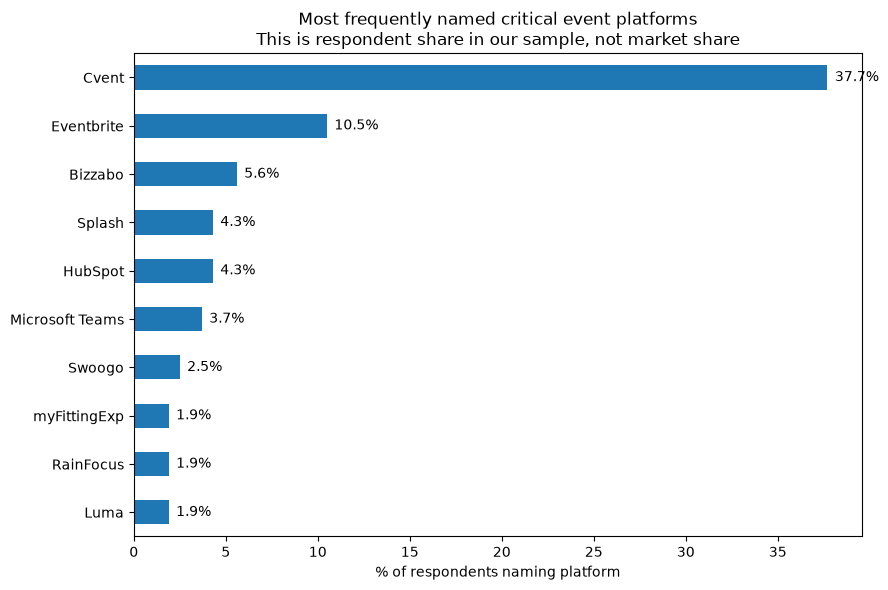

In [47]:
# Top critical platforms after basic cleaning

platform_base = df["platform_clean"].notna().sum()

platform_counts = (
    df["platform_clean"]
    .value_counts()
    .head(10)
)

platform_share = (
    100 * platform_counts / platform_base
).round(1)


ax = platform_share.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

ax.set_title(
    "Most frequently named critical event platforms\n"
    "This is respondent share in our sample, not market share"
)

ax.set_xlabel("% of respondents naming platform")
ax.set_ylabel("")

for i, value in enumerate(platform_share.sort_values()):
    ax.text(
        value + 0.4,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [48]:
cvent_n = (df["platform_clean"] == "Cvent").sum()
eventbrite_n = (df["platform_clean"] == "Eventbrite").sum()

cvent_pct = 100 * cvent_n / platform_base
eventbrite_pct = 100 * eventbrite_n / platform_base

print("Platform answer base:", platform_base)

print(
    f"Cvent: {cvent_n} respondents = {cvent_pct:.1f}%"
)

print(
    f"Eventbrite: {eventbrite_n} respondents = {eventbrite_pct:.1f}%"
)

print(
    f"Cvent is {cvent_n / eventbrite_n:.1f}x Eventbrite after obvious cleaning"
)

Platform answer base: 162
Cvent: 61 respondents = 37.7%
Eventbrite: 17 respondents = 10.5%
Cvent is 3.6x Eventbrite after obvious cleaning


In [71]:
# Extract the numeric NPS score Slide 17

slide17 = df.copy()


# 1. Clean the platform name
slide17["platform_clean"] = (
    slide17[platform_col]
    .astype("string")
    .str.strip()
)

# Standardise obvious Cvent variants
slide17.loc[
    slide17["platform_clean"].str.lower().isin(["cvent", "c-vent"]),
    "platform_clean"
] = "Cvent"


# 2. Extract the numeric NPS score
slide17["nps_numeric"] = pd.to_numeric(
    slide17[nps_col]
    .astype("string")
    .str.extract(r"(\d+)")[0],
    errors="coerce"
)


# 3. Create NPS group
slide17["nps_group"] = pd.Series(
    pd.NA,
    index=slide17.index,
    dtype="string"
)

slide17.loc[
    slide17["nps_numeric"] >= 9,
    "nps_group"
] = "Promoter"

slide17.loc[
    slide17["nps_numeric"].between(7, 8),
    "nps_group"
] = "Passive"

slide17.loc[
    slide17["nps_numeric"] <= 6,
    "nps_group"
] = "Detractor"


# 4. Keep Cvent respondents only
cvent_data = slide17[
    slide17["platform_clean"] == "Cvent"
].copy()


print("Cvent respondents:", len(cvent_data))

display(
    cvent_data["nps_group"]
    .value_counts(dropna=False)
    .to_frame("n")
)

Cvent respondents: 61


,n
nps_group,
Promoter,33
Passive,27
<NA>,1


In [72]:
cvent_scores = cvent_data["nps_numeric"].dropna()

promoters = (cvent_scores >= 9).sum()
passives = cvent_scores.between(7, 8).sum()
detractors = (cvent_scores <= 6).sum()

n = len(cvent_scores)

cvent_nps = (
    100 * promoters / n
    -
    100 * detractors / n
)

print("Cvent NPS base:", n)
print("Promoters:", promoters)
print("Passives:", passives)
print("Detractors:", detractors)
print("Cvent NPS:", round(cvent_nps, 1))

Cvent NPS base: 60
Promoters: 33
Passives: 27
Detractors: 0
Cvent NPS: 55.0


In [73]:
promoter_comments = (
    cvent_data.loc[
        cvent_data["nps_group"] == "Promoter",
        nps_reason_col
    ]
    .dropna()
    .astype("string")
    .str.lower()
)

print("Promoter comments:", len(promoter_comments))

Promoter comments: 33


In [74]:
themes = {

    "Efficiency / streamlining":
        r"efficien|streamlin|simplif|save.*time|saves.*time|reduces manual|manual coordination|centraliz",

    "Ease / usability":
        r"easy to use|ease of use|user-friendly|simple to use|makes.*easier|easier",

    "Reliability / stability":
        r"reliab|dependab|stabil",

    "Broad / end-to-end capability":
        r"entire process|one place|all in one|registration to post-event|covers most|many functionalities|consolidated system",

    "Integration / data":
        r"integrat|crm|marketing and sales systems|data flow|sync",

    "Scale / large-event support":
        r"scalab|large conferences|big events|larger numbers|large programs|sizable|portfolio",

    "ROI / revenue / impact":
        r"\broi\b|revenue|pipeline|conversion|measure the impact|impact of events"
}

In [75]:
theme_results = []

for theme, pattern in themes.items():

    count = (
        promoter_comments
        .str.contains(
            pattern,
            regex=True,
            na=False
        )
        .sum()
    )

    theme_results.append({
        "Theme": theme,
        "Comments": int(count)
    })


theme_df = pd.DataFrame(theme_results)

theme_df = theme_df.sort_values(
    "Comments",
    ascending=True
)

display(theme_df)

,Theme,Comments
6,ROI / revenue / impact,1
4,Integration / data,4
5,Scale / large-event support,5
3,Broad / end-to-end capability,6
2,Reliability / stability,7
1,Ease / usability,10
0,Efficiency / streamlining,13


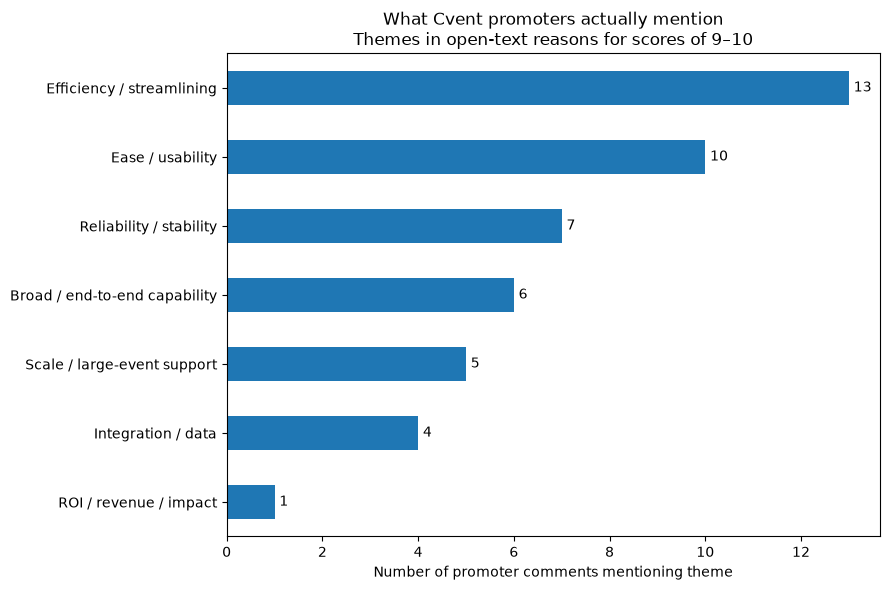

In [76]:
ax = theme_df.plot(
    x="Theme",
    y="Comments",
    kind="barh",
    figsize=(9, 6),
    legend=False
)

ax.set_title(
    "What Cvent promoters actually mention\n"
    "Themes in open-text reasons for scores of 9–10"
)

ax.set_xlabel(
    "Number of promoter comments mentioning theme"
)

ax.set_ylabel("")

for i, value in enumerate(theme_df["Comments"]):

    ax.text(
        value + 0.1,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()
plt.show()

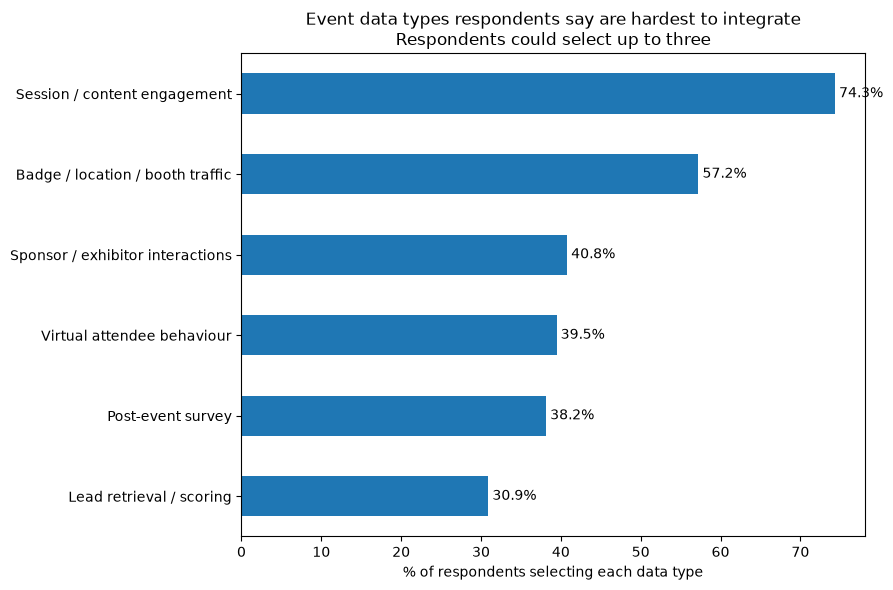

Base: 152

IMPORTANT: 'Registration/contact data' was NOT included as an answer option in this question.


In [50]:
# Slide 25

hard_data_options = {

    "Session / content engagement":
        "Session or content engagement data",

    "Badge / location / booth traffic":
        "Badge scan / physical location / booth traffic data",

    "Sponsor / exhibitor interactions":
        "Sponsor or exhibitor interaction data",

    "Virtual attendee behaviour":
        "Virtual / hybrid attendee behaviour data",

    "Post-event survey":
        "Post-event survey or satisfaction data",

    "Lead retrieval / scoring":
        "Lead-retrieval / scoring data"
}


hard_base = df[hard_data_col].notna().sum()

hard_results = {}

for label, answer in hard_data_options.items():

    count = (
        df[hard_data_col]
        .fillna("")
        .str.contains(
            answer,
            regex=False
        )
        .sum()
    )

    hard_results[label] = (
        100 * count / hard_base
    )


hard_results = (
    pd.Series(hard_results)
    .sort_values()
)


ax = hard_results.plot(
    kind="barh",
    figsize=(9, 6)
)

ax.set_title(
    "Event data types respondents say are hardest to integrate\n"
    "Respondents could select up to three"
)

ax.set_xlabel("% of respondents selecting each data type")
ax.set_ylabel("")

for i, value in enumerate(hard_results):
    ax.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()


print("Base:", hard_base)
print()
print(
    "IMPORTANT: 'Registration/contact data' was NOT included "
    "as an answer option in this question."
)

In [51]:
# Slide 32

ai_ready_score = pd.to_numeric(
    df[ai_ready_col],
    errors="coerce"
)

df["ai_ready_high"] = (
    ai_ready_score >= 4
)

ai_ready_people = df[
    df["ai_ready_high"]
].copy()

print(
    "AI-ready respondents:",
    len(ai_ready_people)
)

AI-ready respondents: 130


In [52]:
# % of respondents rating themselves AI-ready
ai_ready_pct = (
    100 *
    df.loc[
        ai_ready_score.notna(),
        "ai_ready_high"
    ].mean()
)


# Among AI-ready respondents:
# data quality / fragmentation is still their biggest barrier
data_quality_pct = (
    100 *
    (
        ai_ready_people[ai_barrier_col] ==
        "Data quality / fragmentation"
    ).mean()
)


# Single-source-of-truth maturity
moderate_or_lower = [
    "Not at all",
    "To a small extent/ we’re in the early stages",
    "To a moderate extent/ partially"
]

ssot_moderate_or_lower_pct = (
    100 *
    ai_ready_people[ssot_col]
    .isin(moderate_or_lower)
    .mean()
)


# Complete single source of truth among AI-ready respondents
complete_ssot_pct = (
    100 *
    (
        ai_ready_people[ssot_col] ==
        "Completely"
    ).mean()
)


ai_gap = pd.Series({

    "Rate data AI-ready\n(4 or 5)":
        ai_ready_pct,

    "AI-ready but data quality\nis biggest AI barrier":
        data_quality_pct,

    "AI-ready but SSOT is\nmoderate or lower":
        ssot_moderate_or_lower_pct,

    "AI-ready with completely\nunified SSOT":
        complete_ssot_pct

})

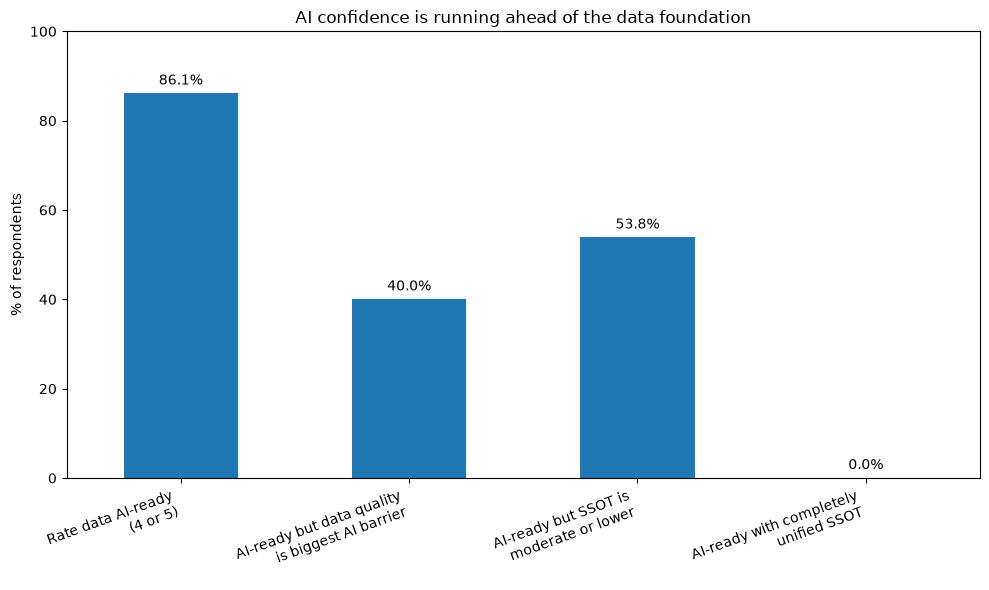

In [53]:
ax = ai_gap.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "AI confidence is running ahead of the data foundation"
)

ax.set_ylabel("% of respondents")
ax.set_xlabel("")
ax.set_ylim(0, 100)

plt.xticks(
    rotation=20,
    ha="right"
)

for i, value in enumerate(ai_gap):
    ax.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [54]:
# Slide 35

roi_cross = pd.crosstab(
    df[roi_level_col],
    df[roi_measure_col]
)

display(roi_cross)

Can you measure the pipeline or revenue contribution of your events in any form?,No,"Yes, fully","Yes, partially"
At what level is event ROI typically measured?,,,
Individual event level only,0,3,9
Not measured,1,0,0
Programme level (across a series of events),0,6,43
Tied to broader business/revenue outcomes,0,6,82


In [55]:
business_roi = df[
    df[roi_level_col] ==
    "Tied to broader business/revenue outcomes"
].copy()


business_roi_ability = (
    business_roi[roi_measure_col]
    .value_counts(normalize=True)
    .mul(100)
)


display(
    business_roi_ability
    .round(1)
    .to_frame("%")
)

,%
Can you measure the pipeline or revenue contribution of your events in any form?,
"Yes, partially",93.2
"Yes, fully",6.8


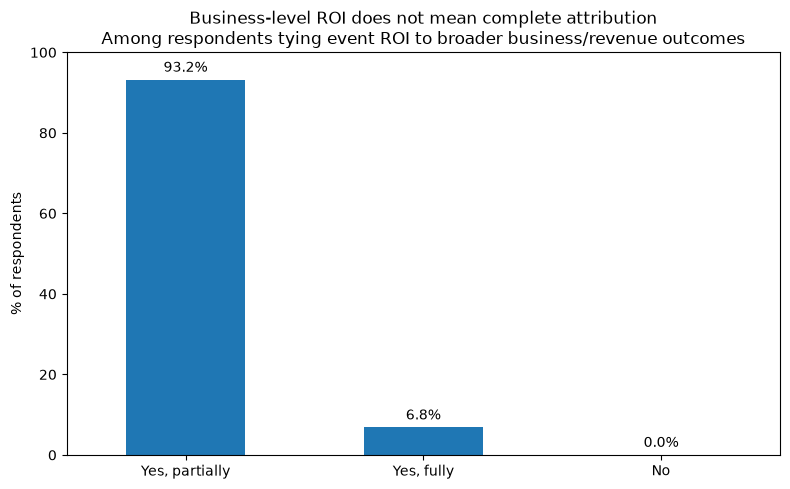

In [56]:
order = [
    "Yes, partially",
    "Yes, fully",
    "No"
]

business_roi_ability = (
    business_roi_ability
    .reindex(order)
    .fillna(0)
)


ax = business_roi_ability.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title(
    "Business-level ROI does not mean complete attribution\n"
    "Among respondents tying event ROI to broader business/revenue outcomes"
)

ax.set_ylabel("% of respondents")
ax.set_xlabel("")
ax.set_ylim(0, 100)

plt.xticks(
    rotation=0
)

for i, value in enumerate(business_roi_ability):
    ax.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [70]:
# Reload a completely fresh copy of the raw file, columns containing actual survey answers for duplications of partials and completed ones


raw_df = pd.read_excel("EventTech2026.xlsx")

print("Raw rows:", len(raw_df))
print("Raw columns:", len(raw_df.columns))

Raw rows: 172
Raw columns: 40


In [64]:
status_col = "Response status"
id_col = raw_df.columns[0]

# Only the original survey-question columns
survey_columns = list(raw_df.columns[2:])

partial_rows = raw_df[
    raw_df[status_col] == "PARTIAL"
]

completed_rows = raw_df[
    raw_df[status_col] == "COMPLETED"
]

duplicate_matches = []


for partial_index, partial_row in partial_rows.iterrows():

    # Questions actually answered in this partial response
    answered_columns = [
        col for col in survey_columns
        if pd.notna(partial_row[col])
    ]

    for completed_index, completed_row in completed_rows.iterrows():

        all_match = True

        for col in answered_columns:

            partial_value = str(partial_row[col]).strip()
            completed_value = str(completed_row[col]).strip()

            if partial_value != completed_value:
                all_match = False
                break

        if all_match:

            duplicate_matches.append({
                "Partial ID": partial_row[id_col],
                "Completed ID": completed_row[id_col],
                "Exact matching answers": len(answered_columns)
            })


duplicate_matches = pd.DataFrame(duplicate_matches)

display(
    duplicate_matches.sort_values(
        "Exact matching answers",
        ascending=False
    )
)

,Partial ID,Completed ID,Exact matching answers
3,131,129,35
7,50,49,32
9,7,6,15
0,104,103,12
2,58,56,12
4,132,129,12
8,66,65,12
6,133,129,11
1,152,151,9
5,136,135,9


In [65]:
n_completed = (
    raw_df[status_col] == "COMPLETED"
).sum()

n_partial = (
    raw_df[status_col] == "PARTIAL"
).sum()

n_suspected_duplicates = (
    duplicate_matches["Partial ID"]
    .nunique()
)

n_remaining_partial = (
    n_partial - n_suspected_duplicates
)

print("Completed:", n_completed)
print("Partial:", n_partial)
print("Suspected duplicate partials:", n_suspected_duplicates)
print("Other partials:", n_remaining_partial)

print()
print("Raw Excel rows:", len(raw_df))
print(
    "Rows excluding suspected duplicate partials:",
    len(raw_df) - n_suspected_duplicates
)

Completed: 149
Partial: 23
Suspected duplicate partials: 12
Other partials: 11

Raw Excel rows: 172
Rows excluding suspected duplicate partials: 160


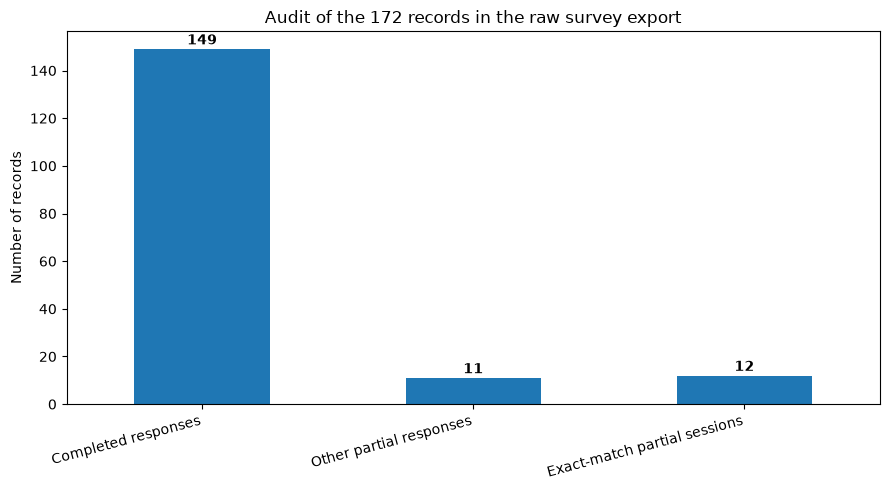

In [66]:
response_audit = pd.DataFrame({
    "Type": [
        "Completed responses",
        "Other partial responses",
        "Exact-match partial sessions"
    ],
    "Records": [
        149,
        11,
        12
    ]
})


ax = response_audit.plot(
    x="Type",
    y="Records",
    kind="bar",
    legend=False,
    figsize=(9, 5)
)

ax.set_title(
    "Audit of the 172 records in the raw survey export"
)

ax.set_ylabel("Number of records")
ax.set_xlabel("")

plt.xticks(
    rotation=15,
    ha="right"
)

for i, value in enumerate(response_audit["Records"]):
    ax.text(
        i,
        value + 2,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [67]:
print(
    "12 of the 23 partial records exactly match a completed response "
    "on every survey question they answered."
)

print(
    f"That is {12/23*100:.1f}% of all partial records."
)

12 of the 23 partial records exactly match a completed response on every survey question they answered.
That is 52.2% of all partial records.


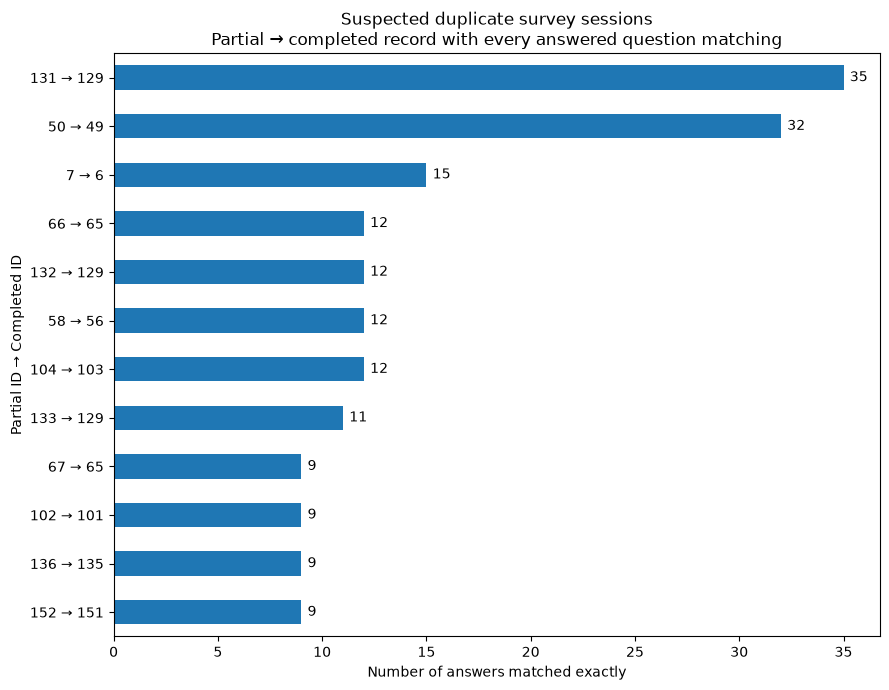

In [68]:
plot_data = (
    duplicate_matches
    .sort_values("Exact matching answers")
    .copy()
)

plot_data["Match"] = (
    plot_data["Partial ID"].astype(str)
    + " → "
    + plot_data["Completed ID"].astype(str)
)


ax = plot_data.plot(
    x="Match",
    y="Exact matching answers",
    kind="barh",
    legend=False,
    figsize=(9, 7)
)

ax.set_title(
    "Suspected duplicate survey sessions\n"
    "Partial → completed record with every answered question matching"
)

ax.set_xlabel(
    "Number of answers matched exactly"
)

ax.set_ylabel(
    "Partial ID → Completed ID"
)

for i, value in enumerate(
    plot_data["Exact matching answers"]
):
    ax.text(
        value + 0.3,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()
plt.show()